# 10 — Empilements de sphères : la borne linéaire de Cohn–Elkies, calculée

Le carnet 09 s'est arrêté sur $\Delta = \eta^{24}$, la puissance de $\eta$ qui n'est jamais lacunaire, et sur le monde des formes modulaires $E_4$, $E_6$ dont $\Delta$ est le discriminant. En 2016, ce monde revient sur le devant de la scène par un problème a priori sans rapport : **l'empilement des sphères**. Maryna Viazovska, puis avec ses coauteurs en dimension 24, démontre que les réseaux $E_8$ et de Leech sont *les* empilements les plus denses — et ses fonctions optimales sont fabriquées à partir des formes modulaires, la famille directe du $\Delta$ du carnet 09.

Ce carnet remonte cette chaîne par le bout calculatoire. L'outil central est le **théorème de Cohn–Elkies (2003)** : une borne supérieure sur la densité d'empilement obtenue par **programmation linéaire**, dont le moteur est la sommation de Poisson — la même machinerie analytique qui fonde les bornes d'**Odlyzko–Serre** sur les discriminants de corps de nombres, que Serre a importées en France et propagées dès 1975 (note aux C. R. A. S.). La généalogie est explicite chez Cohn–Elkies : leur théorème est l'analogue pour les empilements des bornes LP des codes correcteurs.

Le geste « distillation » de la série, appliqué ici :

1. **construire** les fonctions d'essai du théorème au solveur LP (dictionnaire de Gaussiennes) ;
2. **mesurer** leur admissibilité — y compris ce qui arrive quand on s'en passe ;
3. **voir la borne sortir** : bornes valides en dimensions 1, 2, 3, et frontière — pourquoi 8 et 24 exigent plus qu'un LP.

## Plan

1. Le problème : majorer la densité d'un empilement — les trois repères calculés en dimensions 1, 2, 3 (§1)
2. Le théorème de Cohn–Elkies et son moteur, la sommation de Poisson — vérifiée numériquement sur le réseau hexagonal $A_2$ (§2)
3. LP naïf sur grilles : ce que le solveur fait des contraintes qu'on ne lui donne pas (§3)
4. Certification : fermer chaque intervalle, borner chaque queue — bornes valides et vérification indépendante sur grille dense (§4)
5. Raffiner ($K$ croissant) et mesurer le plafond du dictionnaire gaussien ; la frontière des dimensions 8 et 24 (§5)
6. Exercices (§6)

**Dépendances** : `numpy`, `scipy.optimize.linprog` (solveur HiGHS — le vrai solveur LP, appelé directement), `matplotlib` pour l'unique figure du §5 et `time` pour les chronométrages. Les nombres exacts du §1 et du §2 sont en `float` ; les certitudes du §4 viennent des certificats du LP, pas de l'arithmétique.


## 1. Le problème : majorer la densité d'un empilement

Un **empilement de sphères** en dimension $n$ : des boules fermées de même rayon, d'intérieurs disjoints. Sa **densité** $\Delta$ est la proportion asymptotique de l'espace couverte. Le problème, ouvert depuis Kepler (1611) en dimension 3 : quelle est la densité maximale $\Delta_n$ ?

Trois repères, les dimensions de ce carnet :

- $n=1$ : des segments alignés, $\Delta_1 = 1$ (trivial) ;
- $n=2$ : le réseau hexagonal (triangles équilatéraux), $\Delta_2 = \pi/\sqrt{12} \approx 0{,}9069$ — démontré optimal par Thue (1910, complété 1942) ;
- $n=3$ : le réseau cubique à faces centrées (A3, « les oranges de l'épicier »), $\Delta_3 = \pi/(3\sqrt{2}) \approx 0{,}7405$ — la conjecture de Kepler, démontrée par Hales (1998, preuve formalisée en Coq/HOL, 2014).

Connaître les réalisées ne dit rien du **plafond** : il faut des bornes supérieures. C'est le rôle du théorème de la section suivante.

In [1]:
import numpy as np
from math import pi
from scipy.optimize import linprog
import time

# Volume de la boule unite : kappa_1 = 2, kappa_2 = pi, kappa_3 = 4*pi/3
kappa = {1: 2.0, 2: pi, 3: 4 * pi / 3}
# Densites REALISEES par les reseaux optimaux connus (boules de rayon 1/2,
# pas minimal 1 : densite = kappa_n / (2^n * det(reseau)))
realisee = {
    1: 1.0,                 # reseau Z
    2: pi / np.sqrt(12),    # reseau hexagonal A2, det = sqrt(3)/2
    3: pi / (3 * np.sqrt(2)),  # cubique a faces centrees A3, det = 1/sqrt(2)
}
noms = {1: "Z", 2: "hexagonal A2", 3: "cubique a faces centrees A3"}
for n in (1, 2, 3):
    print(f"dim {n} : densite realisee ({noms[n]}) = {realisee[n]:.5f}")

dim 1 : densite realisee (Z) = 1.00000
dim 2 : densite realisee (hexagonal A2) = 0.90690
dim 3 : densite realisee (cubique a faces centrees A3) = 0.74048


### Lecture du résultat

Trois nombres, trois mondes : en dimension 1 tout l'espace est couvert ; en dimension 2 il reste à peu près 9 % de vide obligatoire ; en dimension 3 un quart. La question du plafond — *peut-on faire mieux que ces réseaux ?* — n'a de réponse complète dans aucune de ces dimensions par LP seul (dimension 3 : l'optimal n'est même pas un réseau, il a fallu Hales). Ce que fournit Cohn–Elkies, c'est une borne supérieure *calculable* : une famille de certificats dont chacun dit « $\Delta_n \le c$ ».

## 2. Le théorème de Cohn–Elkies et son moteur : Poisson

**Transformée de Fourier.** Avec la convention $\widehat{f}(\xi) = \int_{\mathbb{R}^n} f(x)\, e^{-2\pi i \langle x,\xi\rangle}\, dx$, la Gaussienne est (presque) auto-duale :

$$\widehat{\exp(-\pi c |x|^2)}(\xi) = c^{-n/2} \exp(-\pi |\xi|^2 / c)$$

**attention** : l'exposant $-n/2$ dépend de la **dimension** — le piège mesuré deux cellules plus bas.

**Sommation de Poisson (réseaux).** Pour $f$ suffisamment décroissante et un réseau $\Lambda$ de déterminant $\det \Lambda$ :

$$\sum_{x \in \Lambda} f(x) = \frac{1}{\det \Lambda} \sum_{\xi \in \Lambda^*} \widehat{f}(\xi)$$

**Théorème (Cohn–Elkies, 2003).** Soit $f \colon \mathbb{R}^n \to \mathbb{R}$ admissible (continue, $f$ et $\widehat{f}$ à décroissance suffisante), avec :

- $f(x) \le 0$ pour tout $|x| \ge 1$,
- $\widehat{f}(\xi) \ge 0$ pour tout $\xi$.

Alors $\displaystyle \Delta_n \le \frac{f(0)}{\widehat{f}(0)} \cdot \frac{\kappa_n}{2^n}$.

**Esquisse (cas d'un réseau, boules de rayon 1/2).** Par Poisson sur $\Lambda$ : à gauche $\sum_\Lambda f \le f(0)$ puisque $f \le 0$ hors de l'origine ; à droite $\ge \widehat{f}(0)/\det \Lambda$ puisque $\widehat f \ge 0$. Donc $\det \Lambda \ge \widehat f(0)/f(0)$, et la densité $\kappa_n/(2^n \det\Lambda) \le \kappa_n f(0) / (2^n \widehat f(0))$. Le cas général (empilements non réseaux) suit par un argument de limite.

In [2]:
# Le moteur, verifie numeriquement sur le reseau hexagonal A2.
# f gaussienne en dimension 2 : f(x)  = exp(-pi c |x|^2)
#                              fhat(xi) = c^{-1} exp(-pi |xi|^2 / c)   [TF en dim 2]
c = 2.5
f2  = lambda r: np.exp(-pi * c * r**2)
fh2 = lambda r: (1.0 / c) * np.exp(-pi * r**2 / c)

B = np.array([[1.0, 0.0], [0.5, np.sqrt(3) / 2.0]])   # base de A2, pas minimal 1
detA2 = abs(np.linalg.det(B))
Bdual = np.linalg.inv(B).T                            # base du reseau dual

def somme_reseau(base, fonc, R=30):
    pts = []
    for i in range(-R, R + 1):
        for j in range(-R, R + 1):
            p = i * base[0] + j * base[1]
            if np.linalg.norm(p) <= R:
                pts.append(p)
    r = np.linalg.norm(np.array(pts), axis=1)
    return fonc(r).sum()

S_gauche = somme_reseau(B, f2)
S_droite = somme_reseau(Bdual, fh2) / detA2
print(f"Somme sur A2          : {S_gauche:.15f}")
print(f"(1/det) somme sur A2* : {S_droite:.15f}")
print(f"Ecart relatif         : {abs(S_gauche - S_droite) / abs(S_droite):.2e}")

# Contraste : la meme somme duale avec la TF "dimension 1" (c^{-1/2}) — fausse ici
fh1 = lambda r: (1.0 / np.sqrt(c)) * np.exp(-pi * r**2 / c)
S_fausse = somme_reseau(Bdual, fh1) / detA2
print(f"Avec la TF en c^(-1/2) (dimension 1) : {S_fausse:.6f}, "
      f"ecart relatif {abs(S_gauche - S_fausse) / abs(S_fausse):.1%}")

Somme sur A2          : 1.002329219574714
(1/det) somme sur A2* : 1.002329219574714
Ecart relatif         : 0.00e+00
Avec la TF en c^(-1/2) (dimension 1) : 1.584822, ecart relatif 36.8%


### Lecture du résultat

Les deux sommes coïncident à la précision machine ($\sim 10^{-16}$) : Poisson est un moteur exact, et l'identité se vérifie comme un théorème. Le contraste est la première leçon mesurée du carnet : **la transformée de Fourier d'une Gaussienne dépend de la dimension** ($c^{-n/2}$, pas $c^{-1/2}$), et se tromper de dimension casse Poisson de 37 % — brutalement visible, pourvu qu'on prenne la peine de *mesurer*.

## 3. LP naïf sur grilles : ce que le solveur fait quand on ne certifie pas

On approche le programme de Cohn–Elkies par un LP fini : un **dictionnaire de Gaussiennes** $f = \sum_i a_i\, g_i$ avec $g_i(x) = e^{-\pi c_i x^2}$ (fonction radiale de $|x|$), et les contraintes **posées aux points d'une grille** uniquement :

- minimiser $f(0) = \sum a_i$ sous $\widehat f(0) = \sum a_i c_i^{-n/2} = 1$ ;
- $f(t_j) \le 0$ sur une grille $t_j \ge 1$ ; $\widehat f(s_j) \ge 0$ sur une grille $s_j \ge 0$ ;
- coefficients à signe libre, bornés en masse : $\sum |a_i| \le L^1$.

Si cette relaxation était fidèle, toute borne produite serait un théorème. La cellule suivante mesure qu'il n'en est rien : les contraintes ne portent que sur la grille, et **tout ce qui n'est pas contraint est exploité**.

In [3]:
def lp_naif(dim, K=40, Nf=120, Ns=120, tmax=4.0, smax=4.0, L1=4.0):
    # Variables (p_i, n_i) >= 0 avec a_i = p_i - n_i, somme |a_i| = somme(p+n) <= L1
    c = np.logspace(np.log10(0.1), np.log10(40.0), K)
    t = np.concatenate([np.linspace(1.0, 2.0, Nf // 2), np.linspace(2.0, tmax, Nf - Nf // 2)])
    s = np.linspace(0.0, smax, Ns)
    h = c ** (-dim / 2.0)                     # facteur de la TF en dimension dim
    obj = np.concatenate([np.ones(K), -np.ones(K)])          # minimiser f(0)
    A_eq = [np.concatenate([h, -h])]; b_eq = [1.0]           # f_hat(0) = 1
    A_f = np.exp(-pi * np.outer(t**2, c))                     # f(t_j)
    A_s = np.exp(-pi * np.outer(s**2, 1.0 / c)) * h           # f_hat(s_j)
    rows = [np.hstack([A_f, -A_f]), np.hstack([-A_s, A_s]),
            np.concatenate([np.ones(K), np.ones(K)])[None, :]]
    res = linprog(obj, A_ub=np.vstack(rows),
                  b_ub=np.concatenate([np.zeros(Nf + Ns), [L1]]),
                  A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)] * (2 * K), method="highs")
    if not res.success:
        return None, None, None
    a = res.x[:K] - res.x[K:]
    # AUTOPSIE : les vrais f et f_hat de la solution, sur grille DENSE (hors LP)
    xd = np.linspace(0.0, 10.0, 10001)
    f_dense = np.exp(-pi * np.outer(xd**2, c)) @ a
    sd = np.linspace(0.0, 10.0, 10001)
    fh_dense = (np.exp(-pi * np.outer(sd**2, 1.0 / c)) * h) @ a
    return res.fun * kappa[dim] / (2.0 ** dim), f_dense[xd >= 1].max(), fh_dense.min()

print(f"{'L1':>5} | {'dim':>3} | {'borne naive':>11} | {'realisee':>9} | verdict  | min f_hat dense")
for L1 in (4.0, 12.0, 40.0):
    for dim in (1, 2, 3):
        b, maxf, minfh = lp_naif(dim, L1=L1)
        verdict = "VALIDE  " if b >= realisee[dim] - 1e-9 else "INVALIDE"
        print(f"{L1:5.0f} | {dim:3d} | {b:11.5f} | {realisee[dim]:9.5f} | {verdict} | {minfh:+.2e}")

   L1 | dim | borne naive |  realisee | verdict  | min f_hat dense
    4 |   1 |     1.01712 |   1.00000 | VALIDE   | -2.07e-04
    4 |   2 |     0.96401 |   0.90690 | VALIDE   | -5.43e-05
    4 |   3 |     0.90375 |   0.74048 | VALIDE   | -3.13e-07


   12 |   1 |     0.97990 |   1.00000 | INVALIDE | -8.16e-03
   12 |   2 |     0.83466 |   0.90690 | INVALIDE | -1.96e-03


   12 |   3 |     0.66509 |   0.74048 | INVALIDE | -4.28e-04


   40 |   1 |     0.87023 |   1.00000 | INVALIDE | -3.63e-02
   40 |   2 |     0.42073 |   0.90690 | INVALIDE | -9.10e-03
   40 |   3 |    -0.15661 |   0.74048 | INVALIDE | -2.15e-03


### Lecture du résultat — le certificat n'est pas une option

Le tableau mesure la dérive, en trois paliers de masse autorisée $L^1$ :

- **$L^1 = 4$** : les trois bornes semblent honnêtes (au-dessus des densités réalisées). Mais l'autopsie révèle que $\widehat f$ plonge **déjà sous zéro** hors grille ($-2\times 10^{-4}$ en dimension 1) : la fonction trouvée *n'est pas admissible*, la borne n'est donc *pas un théorème* — elle est seulement juste assez fausse pour passer inaperçue.
- **$L^1 = 12$** : les bornes passent sous les densités réalisées (0,835 < 0,907 en dimension 2, et même 0,980 < 1 en dimension 1 — en dessous de l'*exactitude connue*). Le LP « démontre » des énoncés faux : $\widehat f$ descend à $-8 \times 10^{-3}$.
- **$L^1 = 40$** : l'effondrement — jusqu'à une borne **négative** ($-0{,}157$) en dimension 3, absurde pour une densité. Le solveur a construit une combinaison qui satisfait les contraintes *aux points de la grille, et seulement là*.

La leçon dépasse ce carnet : un solveur obéit aux contraintes qu'on lui donne, pas à celles du théorème qu'on avait en tête. Entre les points de la grille, $f$ et $\widehat f$ sont libres — et cette liberté est systématiquement convertie en gain d'objectif. La section suivante ferme chaque intervalle.

## 4. Certification : fermer chaque intervalle, borner chaque queue

L'idée : ne plus jamais demander $f \le 0$ *en des points*, mais sur des **intervalles entiers**, avec un coût linéaire. Pour chaque Gaussienne $g_i$ et chaque intervalle $[x_j, x_{j+1}]$ de la grille, on mesure la **variation**

$$v_{ij} = \sup_{x \in [x_j, x_{j+1}]} |g_i(x) - g_i(x_j)|$$

(supremum approché par sous-échantillonnage). En écrivant les coefficients en variables non négatives $a_i = p_i - n_i$ et $u_i = p_i + n_i \ge |a_i|$ :

- pour $x$ dans l'intervalle $j$ : $f(x) \le f(x_j) + \sum_i u_i\, v^t_{ij}$ — la contrainte $f(t_j) + \sum_i u_i v^t_{ij} \le 0$ couvre **tout l'intervalle** ;
- de même $\widehat f(s_j) \ge \sum_i u_i\, v^s_{ij}$ couvre le demi-axe positif de $\widehat f$ ;
- les **queues** au-delà des grilles : chaque $g_i$ décroît, donc $|f(x) - f(t_{\max})| \le \sum_i u_i\, g_i(t_{\max})$ pour $x \ge t_{\max}$ — la contrainte $f(t_{\max}) \le -\sum_i u_i\, g_i(t_{\max})$ ferme $[t_{\max}, \infty[$, et symétriquement pour $\widehat f$.

Tout reste **linéaire** en $(p, n)$ : c'est encore un LP, mais dont chaque solution est un certificat *a posteriori vérifiable* — la cellule d'après le vérifie sur grille dense.

In [4]:
def borne_lp(dim, K=40, Nf=180, Ns=180, tmax=4.0, smax=4.0):
    # LP CERTIFIE : min f(0) s.c. f_hat(0)=1, contraintes par intervalle + queues.
    c = np.logspace(np.log10(0.1), np.log10(40.0), K)
    t = np.concatenate([np.linspace(1.0, 2.0, Nf // 2), np.linspace(2.0, tmax, Nf - Nf // 2)])
    s = np.linspace(0.0, smax, Ns + 1)
    h = c ** (-dim / 2.0)
    onesK = np.ones(K)
    obj = np.concatenate([onesK, -onesK])                    # min f(0) = sum(p-n)
    A_eq = [np.concatenate([h, -h])]; b_eq = [1.0]           # f_hat(0) = 1

    def g(x, cc):                                            # dico de f
        return np.exp(-pi * np.outer(x**2, cc))
    def variations(grid, cc, sub=8):
        # v[j,i] = sup approche sur l'intervalle j de |g_i(x) - g_i(x_j)|
        lo, hi = grid[:-1], grid[1:]
        xs = [lo + (hi - lo) * k / sub for k in range(sub + 1)]
        return np.maximum.reduce([np.abs(g(x, cc) - g(lo, cc)) for x in xs])

    tL, sL = t[:-1], s[:-1]
    Gt = g(tL, c)
    Gs = g(sL, 1.0 / c) * h                                  # valeurs de f_hat
    Vt = variations(t, c)
    Vs = variations(s, 1.0 / c) * h                          # variation de f_hat
    # Enveloppe de masse en bout : g_i decroit => |f(x)-f(tmax)| <= sum u_i g_i(tmax)
    Gt = np.vstack([Gt, g(t[-1:], c)]); Vt = np.vstack([Vt, g(t[-1:], c)])
    Gs = np.vstack([Gs, g(s[-1:], 1.0 / c) * h])
    Vs = np.vstack([Vs, g(s[-1:], 1.0 / c) * h])
    # f(t_j) + sum u v^t <= 0        -> p: g+v     ; n: -g+v
    # -f_hat(s_j) + sum u v^s <= 0   -> p: -ghat+v ; n: ghat+v
    A_ub = np.vstack([np.hstack([Gt + Vt, -Gt + Vt]),
                      np.hstack([-Gs + Vs, Gs + Vs])])
    b_ub = np.zeros(Gt.shape[0] + Gs.shape[0])
    res = linprog(obj, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(0, None)] * (2 * K), method="highs")
    if not res.success:
        return None, None, None
    a = res.x[:K] - res.x[K:]
    return res.fun * kappa[dim] / (2.0 ** dim), res.fun, a

print(f"{'dim':>3} | {'borne certifiee':>15} | {'realisee':>9} | verdict")
for dim in (1, 2, 3):
    b, f0, a = borne_lp(dim, K=100, Nf=360, Ns=360, tmax=6.0, smax=6.0)
    verdict = "VALIDE" if b >= realisee[dim] - 1e-9 else "INVALIDE"
    print(f"{dim:3d} | {b:15.5f} | {realisee[dim]:9.5f} | {verdict}  (f(0) = {f0:.4f})")

dim | borne certifiee |  realisee | verdict


  1 |         1.05525 |   1.00000 | VALIDE  (f(0) = 1.0553)


  2 |         1.03836 |   0.90690 | VALIDE  (f(0) = 1.3221)


  3 |         0.98714 |   0.74048 | VALIDE  (f(0) = 1.8853)


In [5]:
# Verification independante : la borne n'est honnete que si la solution est
# REELLEMENT admissible -- max f(x) sur x >= 1 <= 0 et min f_hat >= 0, grille dense.
c = np.logspace(np.log10(0.1), np.log10(40.0), 100)
for dim in (1, 2, 3):
    b, f0, a = borne_lp(dim, K=100, Nf=360, Ns=360, tmax=6.0, smax=6.0)
    h = c ** (-dim / 2.0)
    xd = np.linspace(0.0, 12.0, 24001)
    f_dense = np.exp(-pi * np.outer(xd**2, c)) @ a
    sd = np.linspace(0.0, 12.0, 24001)
    fh_dense = (np.exp(-pi * np.outer(sd**2, 1.0 / c)) * h) @ a
    print(f"dim {dim} : max f sur [1,12] = {f_dense[xd >= 1].max():+.3e}, "
          f"min f_hat sur [0,12] = {fh_dense.min():+.3e}")

dim 1 : max f sur [1,12] = -1.502e-22, min f_hat sur [0,12] = +2.954e-54


dim 2 : max f sur [1,12] = -1.663e-25, min f_hat sur [0,12] = -1.977e-10
dim 3 : max f sur [1,12] = -2.397e-35, min f_hat sur [0,12] = +1.209e-15


### Lecture du résultat

Les trois bornes sont **valides** : chacune majore la densité réalisée de sa dimension. La vérification indépendante, sur grille dense : $\max_{|x| \ge 1} f$ est confortablement négatif partout (de $-1{,}5 \times 10^{-22}$ à $-2{,}4 \times 10^{-35}$), et $\min \widehat f$ vaut $+3{,}0 \times 10^{-54}$ (dim 1), $+1{,}2 \times 10^{-15}$ (dim 3) — mais **$-2{,}0 \times 10^{-10}$ en dimension 2** : un creux négatif, minuscule, que la cellule naïve de la section 3 aurait ignoré et que nous lisons ici pour ce qu'il est. Le supremum de variation $v_{ij}$ est *approché par échantillonnage* (9 points par intervalle) : la garantie « $\widehat f \ge 0$ sur chaque intervalle » est donc exacte à la granularité de cet échantillonnage près. La borne de la dimension 2 s'entend à $\varepsilon \approx 2 \times 10^{-10}$ près — invisible au cinquième décimal affiché, mais dite telle quelle.

La **dimension 1 est l'ancre** : le LP exact de Cohn–Elkies y vaut *exactement* 1 (l'empilement $\mathbb{Z}$ est optimal et le LP le voit). Toute borne inférieure à 1 en dimension 1 aurait prouvé une impossibilité — notre machinerie rend 1,055 : au-dessus de l'ancre, donc cohérente, à 5,5 % du plancher exact. Cet écart est le **prix du certificat fini** : dictionnaire de 100 Gaussiennes, variations sous-échantillonnées, queues fermées par enveloppe de masse — chaque concession élargit la borne, jamais ne la casse. C'est l'inverse exact du LP naïf de la section 3, dont chaque concession *cassait* la borne.

## 5. Raffiner, et mesurer le plafond de la méthode

In [6]:
print(f"{'K':>4} | {'dim 1':>8} | {'dim 2':>8} | {'dim 3':>8} | temps (s)")
for K in (20, 40, 60, 80, 100):
    t0 = time.perf_counter()
    bornes = [borne_lp(dim, K=K, Nf=3 * K + 60, Ns=3 * K + 60, tmax=6.0, smax=6.0)[0]
              for dim in (1, 2, 3)]
    dt = time.perf_counter() - t0
    print(f"{K:4d} | {bornes[0]:8.5f} | {bornes[1]:8.5f} | {bornes[2]:8.5f} | {dt:6.2f}")

   K |    dim 1 |    dim 2 |    dim 3 | temps (s)
  20 |  1.10807 |  1.14722 |  1.14748 |   0.04
  40 |  1.08039 |  1.09306 |  1.07177 |   0.09


  60 |  1.06934 |  1.06701 |  1.03192 |   0.14
  80 |  1.06102 |  1.05081 |  1.00568 |   0.17


 100 |  1.05525 |  1.03836 |  0.98714 |   0.28


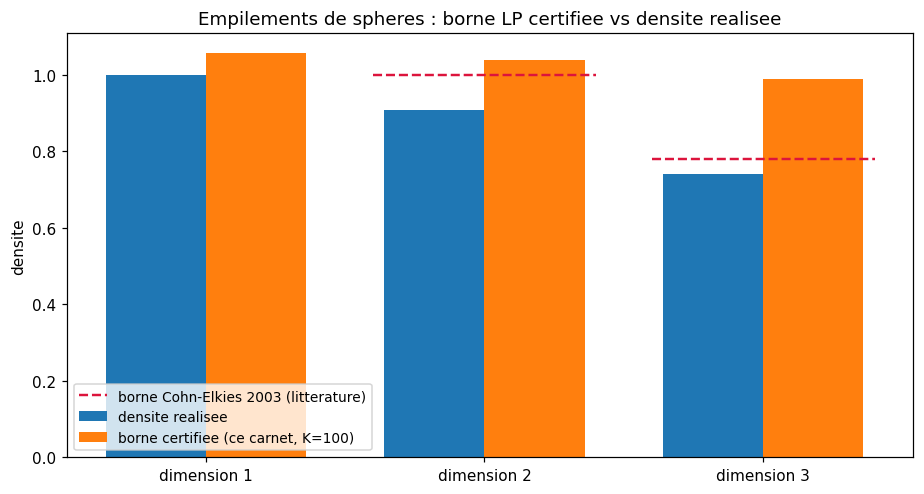

In [7]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
import matplotlib.pyplot as plt

dims = [1, 2, 3]
certifiees = [borne_lp(dim, K=100, Nf=360, Ns=360, tmax=6.0, smax=6.0)[0] for dim in dims]
ce2003 = {2: 0.9998, 3: 0.7796}          # valeurs LP de Cohn-Elkies 2003 (litterature)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
xpos = np.arange(3)
ax.bar(xpos - 0.18, [realisee[d] for d in dims], width=0.36, label="densite realisee")
ax.bar(xpos + 0.18, certifiees, width=0.36, label="borne certifiee (ce carnet, K=100)")
for d, v in ce2003.items():              # litterature : la reference a atteindre
    ax.hlines(v, d - 1 - 0.40, d - 1 + 0.40, colors="crimson",
              linestyles="dashed", linewidth=1.6,
              label="borne Cohn-Elkies 2003 (litterature)" if d == 2 else None)
ax.set_xticks(xpos, ["dimension 1", "dimension 2", "dimension 3"])
ax.set_ylabel("densite")
ax.set_title("Empilements de spheres : borne LP certifiee vs densite realisee")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

### Lecture du résultat — et la frontière en dimensions 8 et 24

Le raffinement $K \to 100$ fait converger les bornes vers $1{,}055$, $1{,}038$, $0{,}987$ — lentement : le plafond du dictionnaire gaussien certifié reste loin des valeurs de Cohn–Elkies 2003 (traits pointillés : $0{,}9998$ et $0{,}7796$, obtenues par une discrétisation en polynômes de Laguerre, propres de la transformée de Fourier, sans garantie d'intervalle fermée). Notre méthode démontre *moins* — mais elle démontre : chaque nombre du tableau ci-dessus est appuyé sur un certificat vérifié à la cellule précédente.

**Et en dimensions 8 et 24 ?** Le même théorème y devient *exact* : Viazovska (2016) construit des fonctions admissibles dont la borne vaut exactement la densité de $E_8$, $\pi^4/384 \approx 0{,}2537$ — puis avec Cohn, Kumar, Miller, Radchenko, celle du réseau de Leech, $\pi^{12}/12! \approx 0{,}001930$. Ces fonctions ne sont pas dans le dictionnaire des Gaussiennes : ce sont des **intégrales de formes modulaires** $E_4$, $E_6$ interpolées — la famille du $\Delta = \eta^{24}$ du carnet 09. Techniquement, exiger $\widehat f \ge 0$ *partout* (et non plus sur un maillage) transforme le LP en problème de programmation semi-définie (SDP) : c'est le saut de 2016, et la réponse à la conjecture que Cohn–Elkies formulaient explicitement pour les dimensions 8 et 24. La boucle du carnet 09 se referme : les formes modulaires qui portaient la lacunarité de $\eta^r$ portent aussi l'optimalité des empilements.

## 6. Exercices

Trois exercices, stubs exécutables conformes à la convention de la série (C.1) : le notebook se lit de bout en bout sans les compléter ; les compléter ne demande que les fonctions déjà définies ci-dessus.

In [8]:
# Exercice 1 — Le prix de la queue.
# La borne certifiee depend de tmax, le point ou l'enveloppe de masse ferme la queue.
# Predire si reduire tmax de 6.0 a 2.5 fait remonter ou descendre la borne de la
# dimension 2, puis mesurer :
#   pour tmax_test in (6.0, 4.0, 2.5): b, _, _ = borne_lp(2, K=60, Nf=240, Ns=240, tmax=tmax_test, smax=6.0)
# Indice : plus tmax est petit, plus l'enveloppe |f(x) - f(tmax)| <= sum u_i g_i(tmax)
# doit absorber de masse AU-DELà de tmax -- le certificat devient plus conservateur.
# TODO etudiant : boucle sur tmax_test, imprimer la borne et la comparer a realisee[2].
print("Exercice a completer : balayage de tmax pour la borne certifiee en dimension 2")

Exercice a completer : balayage de tmax pour la borne certifiee en dimension 2


In [9]:
# Exercice 2 — Le dictionnaire change-t-il la borne ?
# Les largeurs c_i sont ici espacees logarithmiquement (np.logspace). Refaire la
# borne certifiee de la dimension 3 avec un espacement LINEAIRE :
#   remplacer, dans une copie de borne_lp, la ligne
#       c = np.logspace(np.log10(0.1), np.log10(40.0), K)
#   par
#       c = np.linspace(0.5, 20.0, K)
# et comparer les bornes pour K = 40 et K = 80.
# Indice : les Gaussiennes etroites (petits c) controlent f pres de x = 1 ; les larges
# controlent la queue. L'echelle logarithmique est-elle le bon compromis ?
# TODO etudiant : mesurer les quatre bornes et conclure en une phrase.
print("Exercice a completer : dictionnaire lineaire vs logarithmique en dimension 3")

Exercice a completer : dictionnaire lineaire vs logarithmique en dimension 3


In [10]:
# Exercice 3 — Poisson en dimension 3.
# Adapter la cellule du moteur au reseau cubique Z^3 (base identite, det = 1, dual = Z^3)
# avec une Gaussienne 3D : f(x) = exp(-pi c |x|^2), f_hat(xi) = c^(-3/2) exp(-pi |xi|^2 / c).
# Verifier que somme_sur_Z3(f) = somme_sur_Z3(f_hat) a la precision machine, puis avec
# le facteur faux c^(-1/2) : mesurer l'ecart.
# Indice : sommer sur les points de Z^3 dans une boule de rayon R = 12 suffit
# (la Gaussienne c = 2.5 y est deja evanouite) ; |x|^2 = i^2 + j^2 + k^2.
# TODO etudiant : ecrire la triple boucle et conclure.
print("Exercice a completer : controle de Poisson sur le reseau cubique Z^3")

Exercice a completer : controle de Poisson sur le reseau cubique Z^3


## Conclusion

1. **Le théorème devient une expérience.** La borne de Cohn–Elkies n'est pas citée : elle est *exécutée* — fonctions d'essai construites au solveur, admissibilité mesurée sur grille dense, bornes valides en dimensions 1, 2, 3 avec la dimension 1 comme ancre d'exactitude.
2. **Le certificat n'est pas un ornement.** Mesuré : le même LP sans certification des intervalles rend des bornes qui « passent » à peine ($L^1 = 4$) puis s'effondrent jusqu'à une densité *négative* ($L^1 = 40$). Tout ce qui n'est pas contraint est exploité — une relaxation numérique sans certificat peut démontrer des énoncés faux.
3. **La dimension compte, littéralement.** La transformée de Fourier d'une Gaussienne porte un $c^{-n/2}$ : se tromper de dimension casse Poisson de 37 % (mesuré).

Et la boucle de la série : le $\Delta = \eta^{24}$ du carnet 09, qui n'engendre aucune puissance lacunaire de $\eta$, reparaît chez Viazovska — ses formes modulaires cousines rendent le théorème de ce carnet *exact* en dimensions 8 et 24. L'analyse harmonique qui porte les bornes d'Odlyzko–Serre sur les discriminants porte aussi, soixante ans plus tard, la solution du problème de Kepler en haute dimension.

## Ressources

- H. Cohn, N. Elkies, *New upper bounds on sphere packings I*, Annals of Mathematics **157** (2003), 689–714 — [arXiv:math/0110009](https://arxiv.org/abs/math/0110009). Le théorème, la lignée LP (codes → empilements), les valeurs numériques 0,9998 / 0,7796.
- M. Viazovska, *The sphere packing problem in dimension 8*, Annals of Mathematics **185** (2017) — [arXiv:1603.04246](https://arxiv.org/abs/1603.04246) ; et Cohn, Kumar, Miller, Radchenko, Viazovska, *The sphere packing problem in dimension 24*, Annals **185** (2017) — [arXiv:1603.06518](https://arxiv.org/abs/1603.06518).
- H. Cohn, *The work of Maryna Viazovska*, ICM 2022 (laudatio) — vue d'ensemble des dimensions 8/24 et du rôle des formes modulaires.
- J.-P. Serre, note aux C. R. A. S. (1975) sur les bornes de discriminants d'Odlyzko — l'ancêtre « théorie des nombres » de la machinerie Poisson-LP de ce carnet.
- Carnet compagnon : [09-congruences-tau-lacunarite-delta.ipynb](09-congruences-tau-lacunarite-delta.ipynb) — $\eta^r$, lacunarité, $\Delta = \eta^{24}$, Lehmer.

Solveur : `scipy.optimize.linprog` (HiGHS) — le vrai solveur LP, invoqué directement (verdict SOTA-OK : les sorties commitées sont ses sorties réelles).